In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.datasets import load_iris

In [ ]:
#  load data (iris)
iris= load_iris()
X=iris.data
y=iris.target

#Making data Frame and passing training data
df=pd.DataFrame(X, columns=iris.feature_names)
df['target']=y
df.head(10)



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [9]:
# To see the 5 number summary 
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
# Checking the data types and non-null rows
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [11]:
#Checking null rows
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [ ]:
#Checking the duplicates 
df.duplicated().sum()  #1 duplicate is found in the data 

np.int64(1)

In [18]:
#CHecking the row index which are duplicates
df[df.duplicated(keep=False)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
101,5.8,2.7,5.1,1.9,2
142,5.8,2.7,5.1,1.9,2


In [23]:
# Dropping the duplicated row (this will just keep the first occurance, and will drop the rest duplicated rows)
df.drop_duplicates(inplace=True)

In [30]:
#Checking the locations of the both the duplicates after dropping one 
df.iloc[[101,142]]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
101,5.8,2.7,5.1,1.9,2
143,6.8,3.2,5.9,2.3,2


In [31]:
#Checking the shape of the data 
df.shape

(149, 5)

In [32]:
# Working with the target
df['target'].unique()

array([0, 1, 2])

In [34]:
# Class counts
df['target'].value_counts()

target
0    50
1    50
2    49
Name: count, dtype: int64

In [35]:
#Data type of the target
df['target'].dtype

dtype('int64')

In [37]:
#  split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# scale numeric features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#  train models
models = {
    "logreg": LogisticRegression(max_iter=1000, random_state=42),
    "rf"    : RandomForestClassifier(n_estimators=300, random_state=42),
    "svm"   : SVC(probability=True, random_state=42),
    "xgb"   : XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}
for name, m in models.items():
    m.fit(X_train_s, y_train)

# evaluate & compare
rows = []
for name, m in models.items():
    y_pred = m.predict(X_test_s)
    y_proba = m.predict_proba(X_test_s)
    # for multiclass, use 'ovr' AUC; PR-AUC is less standard for multi-class
    roc = roc_auc_score(y_test, y_proba, multi_class="ovr")
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    rows.append({
        "model": name,
        "accuracy": report["accuracy"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "roc_auc_ovr": roc
    })
pd.DataFrame(rows).sort_values("macro_f1", ascending=False)


c:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:54:24] WARNING: D:\bld\xgboost-split_1755048450370\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,model,accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr
2,svm,0.966667,0.969697,0.966667,0.966583,0.996667
0,logreg,0.933333,0.933333,0.933333,0.933333,0.996667
3,xgb,0.933333,0.933333,0.933333,0.933333,0.965000
1,rf,0.900000,0.902357,0.900000,0.899749,0.993333


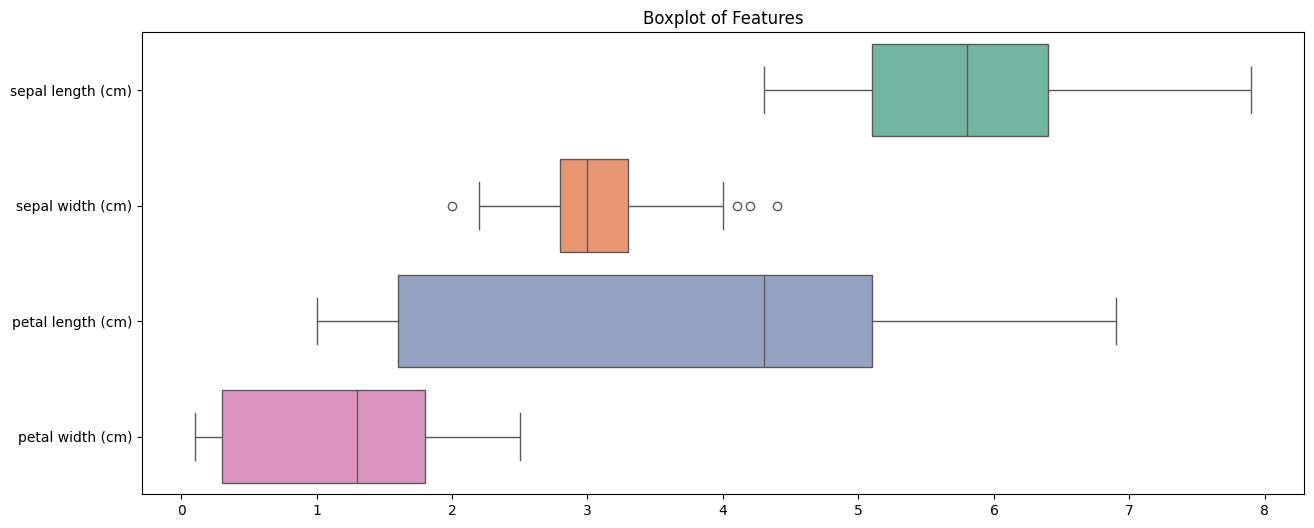

In [ ]:
#Visualization of the Dataset
#BoxPlot to visualize the outliers
sns.boxplot(data=df.drop("target", axis=1), orient="h", palette="Set2")
plt.title("Boxplot of Features")
plt.show()


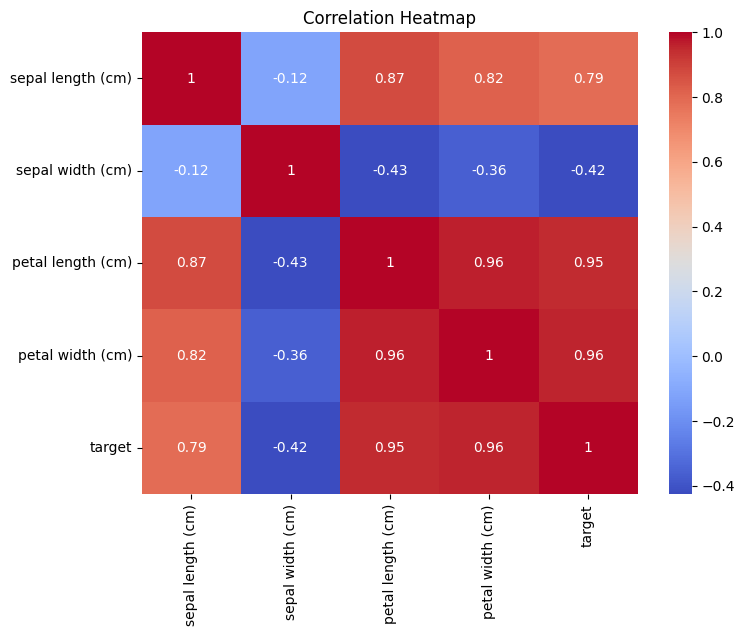

In [45]:
# Correlation Heatmap (for relation between the features)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()


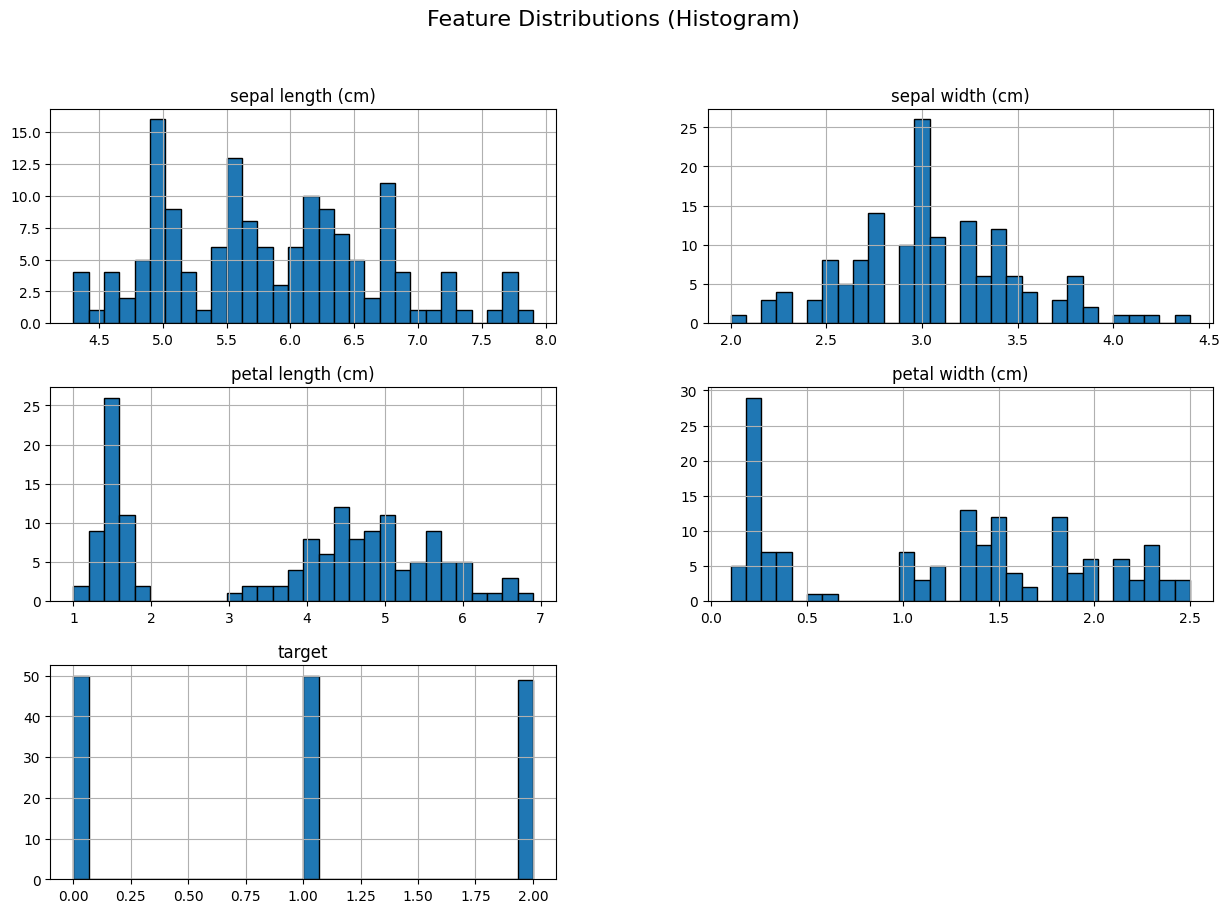

In [46]:
#Histogram of featues 
df.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions (Histogram)", fontsize=16)
plt.show()


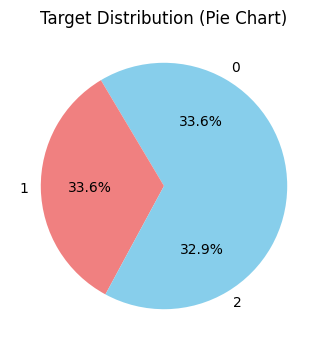

C:\Users\PMLS\AppData\Local\Temp\ipykernel_4252\3064113320.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette=["skyblue", "lightcoral"])
C:\Users\PMLS\AppData\Local\Temp\ipykernel_4252\3064113320.py:12: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x="target", data=df, palette=["skyblue", "lightcoral"])


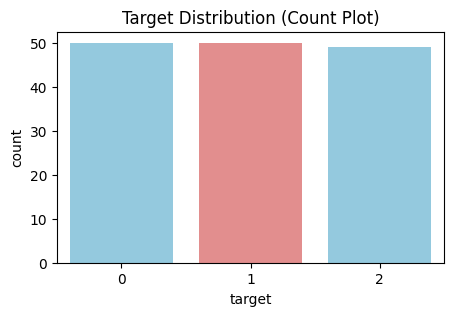

In [51]:
# Pie and Count plot of the target feature

# Pie chart
plt.figure(figsize=(6,4))
df["target"].value_counts().plot.pie(autopct='%1.1f%%', colors=["skyblue", "lightcoral"])
plt.title("Target Distribution (Pie Chart)")
plt.ylabel("")  # removes y-label
plt.show()

# Count plot
plt.figure(figsize=(5,3))
sns.countplot(x="target", data=df, palette=["skyblue", "lightcoral"])
plt.title("Target Distribution (Count Plot)")
plt.show()


=== Classification Report (SVM) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

=== Confusion Matrix (SVM) ===
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


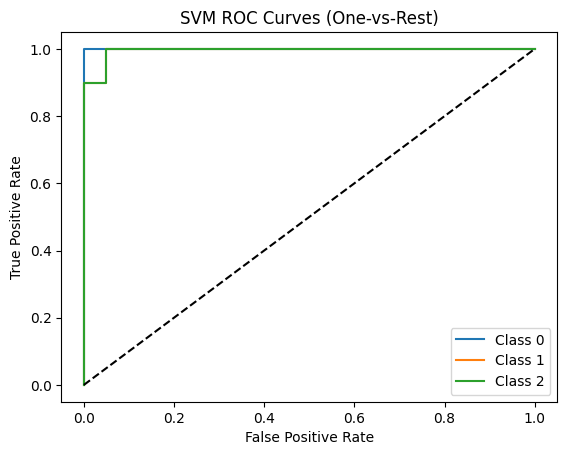

In [ ]:
#  final model (SVM)
final_model = SVC(probability=True, random_state=42)
final_model.fit(X_train_s, y_train)

# evaluate on test set
y_pred = final_model.predict(X_test_s)
y_proba = final_model.predict_proba(X_test_s)

print("=== Classification Report (SVM) ===")
print(classification_report(y_test, y_pred, zero_division=0))

print("=== Confusion Matrix (SVM) ===")
print(confusion_matrix(y_test, y_pred))

# ROC curve (one-vs-rest)
fpr = {}
tpr = {}
for i in range(len(np.unique(y))):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_proba[:, i])
    plt.plot(fpr[i], tpr[i], label=f"Class {i}")
plt.plot([0,1],[0,1],"k--")
plt.title("SVM ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()